# 21 — Structural local-LLM router: lattice + ring state inside the decision

Notebooks 13–18 use a typed decision model (TypeSafe Jev / Rust Laya) as
the router: each step it picks which of the three small LLMs answers.
This notebook swaps in a **local small LLM router** —
`StructuralLlmRouter` — that conditions on the **ewm-sm structural
state**, not just prose:

- `bss`  — soft coverage of each LLM's frame over the conversation,
- `drn`  — Noether D/R/N of the last transition (departed/retained/new
  bits),
- `ring` — Boolean-ring reading (residual, in_span, dim, rotation_count,
  spill_first) = structural novelty of the context,
- `windows` — moving averages of the structural series over the last
  2/3/4/5 steps (multi-window view of the commit history),
- `crossings` — short-vs-long window crossover events (from above /
  from below),
- `memory` — materialized token ids (capped).

The router is a drop-in behind the same `DecisionRouter` seam as
Jev/Laya. The loop runs with `structural=True`, so the state passed to
the router carries the lattice + ring + window fields; every
`(state, options, instructions, decision)` tuple is logged into
`routing_log` — the distillation dataset for the typed-head student.

**Upgrade (this edition):** the structural state now includes the
multi-window moving averages and crossover events, and §3 projects
every lattice commit onto the **per-LLM codebook gates** with the new
G1-scoped `bss_g1` coordinates from `ewm-scene project --frame` — the
commit as a gate event.

Router model: `Qwen/Qwen2.5-1.5B-Instruct` (cached, local). LLMs run
on the RTX 3060 (`CUDA_VISIBLE_DEVICES=1` under
`CUDA_DEVICE_ORDER=PCI_BUS_ID` — override in the first cell if your
enumeration differs).

The run is kept light (`cycles=2`, `T=12` for the structural loop,
`T=8` for the A/B baselines, `max_new_tokens=32`) so the notebook
executes in a few minutes; raise these to `cycles=3` / `T=16` /
`max_new_tokens=48` for the full notebook-16-parity run.

In [1]:
import os, sys, json

# With CUDA_DEVICE_ORDER=PCI_BUS_ID on this machine the Quadro M1200 is
# device 0 and the RTX 3060 is device 1. Hard-set (not setdefault) so a
# stale inherited value cannot pin the kernel to the small Quadro.
# Override the value here if your enumeration differs.
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = "1"
os.environ.setdefault("HF_HUB_DISABLE_PROGRESS_BARS", "1")

import numpy as np
import torch
print("torch sees:", torch.cuda.get_device_name(0),
      round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1), "GB")

EWM_SM = "/home/alexmy/SGS/SGS_lib/fractal_manifold_gen2/ewm-state-machine"
sys.path.insert(0, EWM_SM)

from trainer import (
    EwmScene,
    JevAdapter,
    LayaAdapter,
    LlmAdapter,
    StructuralLlmRouter,
    run_open_loop,
    run_jev_loop,
)

WORK = "/home/alexmy/.cache/ewm-structural-router"
os.makedirs(WORK, exist_ok=True)
ewm = EwmScene()
print("ewm-scene:", ewm.bin)
print("work:", WORK)

torch sees: NVIDIA GeForce RTX 3060 12.5 GB
ewm-scene: /home/alexmy/SGS/SGS_lib/fractal_manifold_gen2/ewm-state-machine/target/debug/ewm-scene
work: /home/alexmy/.cache/ewm-structural-router


In [2]:
QUERIES = [
    "What is the capital of France?",
    "Explain gravity in one sentence.",
    "Write a haiku about rain.",
    "What is the meaning of life?",
    "Name three planets in our solar system.",
    "What is the speed of light?",
    "Define entropy in simple words.",
    "Who wrote Romeo and Juliet?",
]

adapter = LlmAdapter(max_new_tokens=32)     # the three real small LLMs (GPU)
srouter = StructuralLlmRouter(max_new_tokens=128)  # local Qwen structural router (GPU)
jev     = JevAdapter(mock=True)            # deterministic baseline
laya    = LayaAdapter()                    # Rust Laya baseline (CPU, if present)

print("adapter names:", adapter.names)
print("structural router mode:", "mock" if srouter.mock else "real",
      "|", srouter.model_id if not srouter.mock else srouter._mock_reason)
print("Jev mode:", "mock" if jev.mock else "real SDK")
print("Laya mode:", "mock" if laya.mock else "real rust/candle")

adapter names: ('llm_a', 'llm_b', 'llm_c')
structural router mode: real | Qwen/Qwen2.5-1.5B-Instruct
Jev mode: mock
Laya mode: real rust/candle


## §1 — Open loop (same shared context as notebooks 09–18)

In [3]:
open_result = run_open_loop(adapter, ewm, QUERIES, WORK, cycles=2, max_new_tokens=32)
print("IICA (union discovered twice):", open_result.same_union)
print("BSS trajectory:", open_result.M_ol.shape, "| prototypes:", open_result.M_proto.shape)
print("DFT-detected period:", open_result.period, "steps (true period 8)")
print("per-LLM codebook frame:", open_result.frame_path)

IICA (union discovered twice): False
BSS trajectory: (16, 3) | prototypes: (8, 3)
DFT-detected period: 8.0 steps (true period 8)
per-LLM codebook frame: /home/alexmy/.cache/ewm-structural-router/frame_frontends.json


## §2 — Structural router loop (lattice + ring + windows in, typed decision out)

Each step the loop enriches the router state with the latest Noether
D/R/N, Boolean-ring reading, and the multi-window/crossing view
(`structural=True`), then the local Qwen model returns a JSON
decision. Confidence gating and decision-in-state are unchanged from
notebooks 14/16. The full routing log is saved for distillation.

In [4]:
floor = 0.5
fallback = "llm_b"

s_result = run_jev_loop(
    adapter, srouter, ewm, open_result, QUERIES, WORK, T=12, max_new_tokens=32,
    confidence_floor=floor, fallback=fallback, ingest_decision=True,
    structural=True,
)

decisions = s_result.decision_log
print()
print("decision distribution (structural router's choice before gating):")
for name in adapter.names:
    n = sum(1 for d in decisions if d.decision == name)
    print(f"  {name:6s} {n:2d} steps")
print("gated to fallback:", sum(s_result.gated_log), "of", len(s_result.gated_log))
print("mean confidence:", round(float(np.mean([d.confidence for d in decisions])), 4))
print("mean aux noul (needs_memory):",
      round(float(np.mean([d.aux.get("needs_memory", 0.0) for d in decisions])), 4))

# the first structural state with both lattice and ring readings
first = next((r for r in s_result.routing_log
              if "ring" in r["state"] and "drn" in r["state"]), None)
if first:
    print()
    print("first structural state keys:", sorted(first["state"].keys()))
    print("drn :", first["state"].get("drn"))
    print("ring:", first["state"].get("ring"))
    wins = first["state"].get("windows") or {}
    cross = first["state"].get("crossings") or {}
    print("windows sample:", {k: round(v, 2) for k, v in list(wins.items())[:4]})
    print("crossings (true events):", sorted(k for k, v in cross.items() if v))

# persist the distillation dataset
with open(f"{WORK}/routing_log.jsonl", "w") as fh:
    for r in s_result.routing_log:
        fh.write(json.dumps(r) + "\n")
with open(f"{WORK}/decision_log.jsonl", "w") as fh:
    for d in decisions:
        fh.write(json.dumps(d.to_dict()) + "\n")
print()
print("saved:", f"{WORK}/routing_log.jsonl", "|", f"{WORK}/decision_log.jsonl")

t= 0 q=0  route=llm_c   confidence=1.000  gated=False  mock=False


t= 4 q=4  route=llm_b   confidence=0.000  gated=True  mock=False


t= 8 q=0  route=llm_b   confidence=0.900  gated=False  mock=False


t=11 q=3  route=llm_b   confidence=0.900  gated=False  mock=False

decision distribution (structural router's choice before gating):
  llm_a   0 steps
  llm_b   8 steps
  llm_c   4 steps
gated to fallback: 3 of 12
mean confidence: 0.7
mean aux noul (needs_memory): 0.7083

first structural state keys: ['bss', 'crossings', 'drn', 'memory', 'query', 'ring', 'step', 'windows']
drn : {'dp': 24, 'rp': 24, 'np': 21, 'ind1': 0.5333333333333333, 'ind3': 0.4375}
ring: {'residual': 45, 'in_span': False, 'dim': 2, 'rotation_count': 0, 'spill_first': 21}
windows sample: {'np_ma2': 21.0, 'np_ma3': 21.0, 'np_ma4': 21.0, 'np_ma5': 21.0}
crossings (true events): []

saved: /home/alexmy/.cache/ewm-structural-router/routing_log.jsonl | /home/alexmy/.cache/ewm-structural-router/decision_log.jsonl


In [5]:
from trainer import structural_decision_prompt

sample = next(r for r in s_result.routing_log
              if "ring" in r["state"] and "drn" in r["state"])
prompt = structural_decision_prompt(
    sample["state"], sample["options"], sample["instructions"],
    extra_noul={"needs_memory": "The query requires context from previous answers"},
)
print(prompt)

Query: "Write a haiku about rain."
Memory: 24 content-addressed token ids; most recent: tid287 tid530 tid6827 tid13 tid198 tid20746 tid25 tid48605
BSS coverage (fraction of the conversation each model's frame covers): llm_a 0.031, llm_b 0.025, llm_c 0.071
Noether D/R/N of the last transition (departed/retained/new bits): dp=24 rp=24 np=21
indicators ind1=0.533 ind3=0.438
Boolean-ring reading of the last frame: residual=45 in_span=False dim=2 rotation_count=0 spill_first=21
Moving averages of the structural series over the last 2/3/4/5 steps: bss_llm_a ma2=0.029 ma3=0.029 ma4=0.029 ma5=0.029; bss_llm_b ma2=0.025 ma3=0.025 ma4=0.025 ma5=0.025; bss_llm_c ma2=0.079 ma3=0.079 ma4=0.079 ma5=0.079; dim ma2=1.500 ma3=1.500 ma4=1.500 ma5=1.500; dp ma2=24.000 ma3=24.000 ma4=24.000 ma5=24.000; ind1 ma2=0.533 ma3=0.533 ma4=0.533 ma5=0.533; ind3 ma2=0.438 ma3=0.438 ma4=0.438 ma5=0.438; np ma2=21.000 ma3=21.000 ma4=21.000 ma5=21.000; residual ma2=46.500 ma3=46.500 ma4=46.500 ma5=46.500; rotation_cou

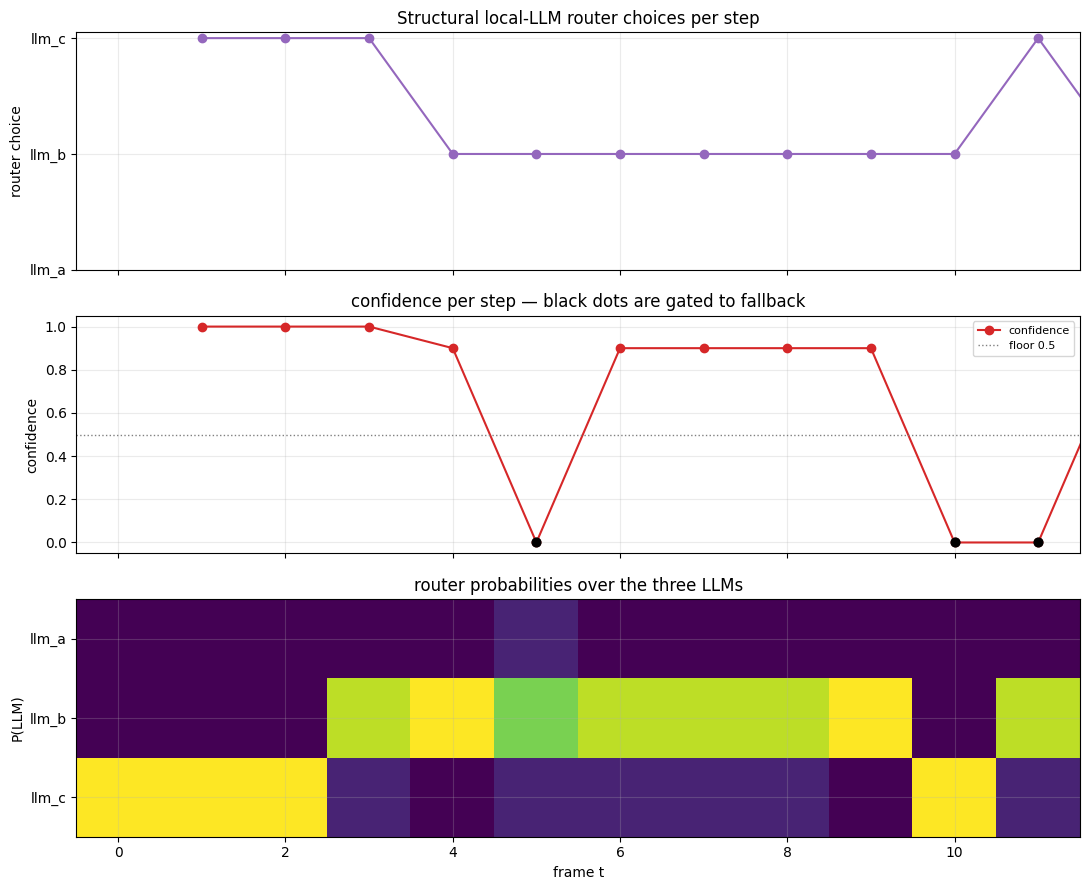

In [6]:
%matplotlib inline
import matplotlib.pyplot as plt

names = list(adapter.names)
T = len(decisions)
t_axis = np.arange(1, T + 1)
conf = [d.confidence for d in decisions]
route_idx = [names.index(d.decision) for d in decisions]
gated = s_result.gated_log

fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)
axes[0].plot(t_axis, route_idx, "o-", color="tab:purple")
axes[0].set_yticks(range(len(names)), names)
axes[0].set_ylabel("router choice")
axes[0].set_title("Structural local-LLM router choices per step")
axes[0].grid(alpha=0.25)

axes[1].plot(t_axis, conf, "o-", color="tab:red", label="confidence")
axes[1].axhline(floor, color="gray", ls=":", lw=1.0, label=f"floor {floor}")
for t, g in enumerate(gated):
    if g:
        axes[1].scatter([t_axis[t]], [conf[t]], color="black", zorder=5, s=40)
axes[1].set_ylabel("confidence")
axes[1].set_title("confidence per step — black dots are gated to fallback")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.25)

P = np.array([[d.probabilities.get(n, 0.0) for n in names] for d in decisions])
axes[2].imshow(P.T, aspect="auto", cmap="viridis", interpolation="nearest")
axes[2].set_yticks(range(len(names)), names)
axes[2].set_ylabel("P(LLM)")
axes[2].set_xlabel("frame t")
axes[2].set_title("router probabilities over the three LLMs")
axes[2].grid(alpha=0.25)

plt.tight_layout()
plt.savefig(f"{WORK}/structural_router.png", dpi=110)
plt.show()

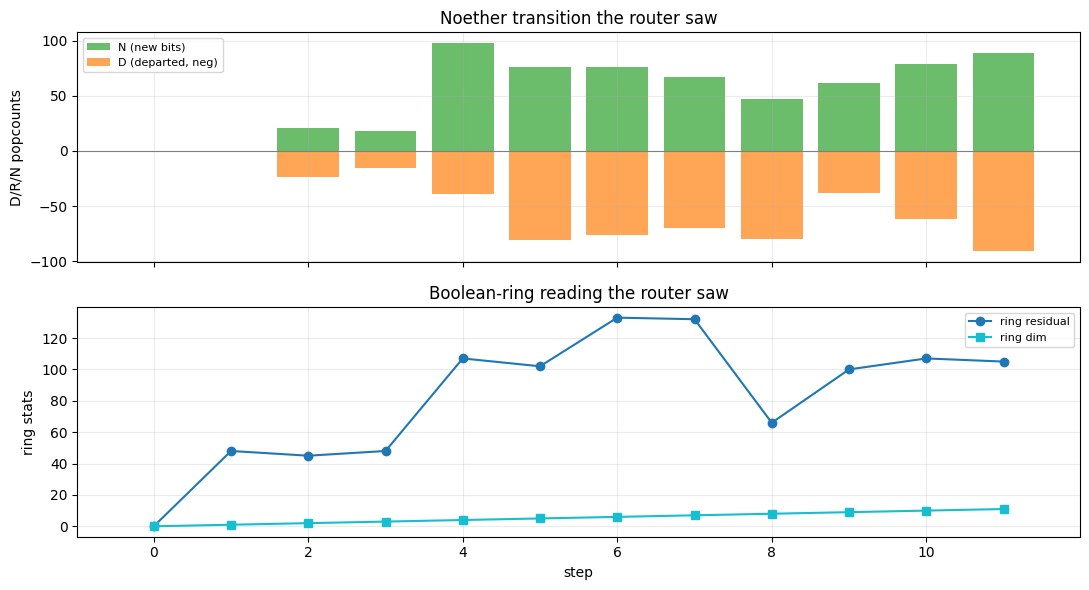

In [7]:
# The structural signal the router conditions on, step by step.
steps = [r["step"] for r in s_result.routing_log]
np_series  = [r["state"].get("drn", {}).get("np", 0) for r in s_result.routing_log]
dp_series  = [r["state"].get("drn", {}).get("dp", 0) for r in s_result.routing_log]
res_series = [r["state"].get("ring", {}).get("residual", 0) for r in s_result.routing_log]
dim_series = [r["state"].get("ring", {}).get("dim", 0) for r in s_result.routing_log]

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
axes[0].bar(steps, np_series, color="tab:green", alpha=0.7, label="N (new bits)")
axes[0].bar(steps, [-d for d in dp_series], color="tab:orange", alpha=0.7, label="D (departed, neg)")
axes[0].axhline(0, color="gray", lw=0.8)
axes[0].set_ylabel("D/R/N popcounts")
axes[0].set_title("Noether transition the router saw")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.25)

axes[1].plot(steps, res_series, "o-", color="tab:blue", label="ring residual")
axes[1].plot(steps, dim_series, "s-", color="tab:cyan", label="ring dim")
axes[1].set_ylabel("ring stats")
axes[1].set_xlabel("step")
axes[1].set_title("Boolean-ring reading the router saw")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.savefig(f"{WORK}/structural_signal.png", dpi=110)
plt.show()

## §3 — The lattice commit as a codebook-gate event (upgrade)

`run_open_loop` already projects the union onto **per-LLM codebook
dimensions** (`frame_frontends.json`): each LLM's cumulative
vocabulary is a catalog gate `G_u = μ(codebook)` (`c:<sha1>` on the
Rust side). With the upgraded `ewm-scene project --frame`, the
coordinates now include the G1-scoped `bss_g1` — the cross-scheme
safe comparison. Each row below is one commit event of the shared
lattice, expressed in the three codebook gates.

codebook gates (per-LLM cumulative vocabularies):
  llm_a  gate pop = 385
  llm_b  gate pop = 433
  llm_c  gate pop = 254


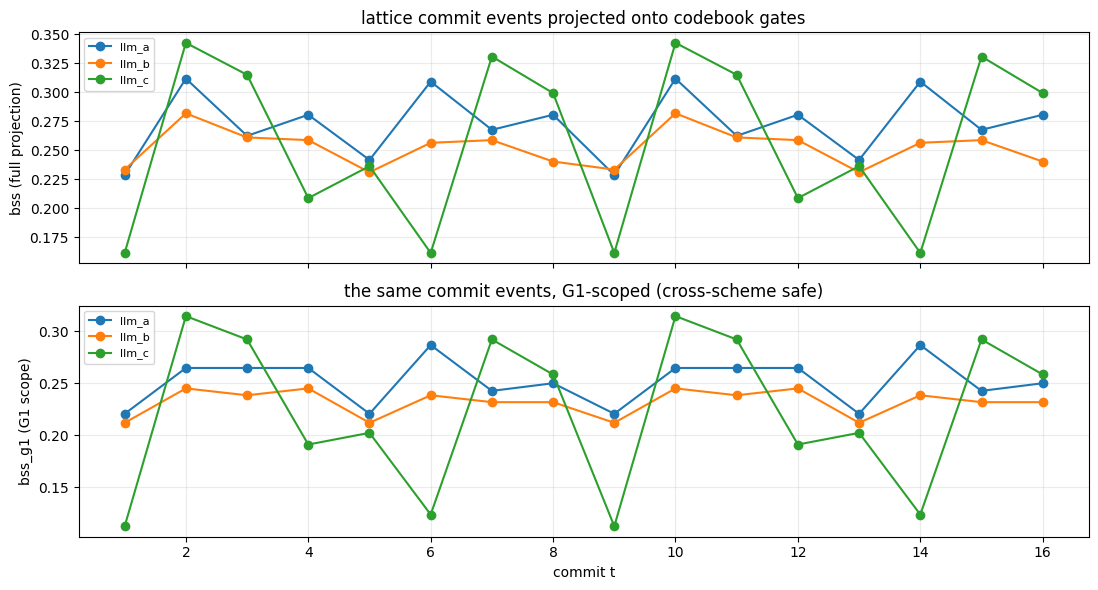

In [8]:
proj = ewm.project(open_result.union_path, open_result.frame_path)
names = open_result.names
M_bss = np.array([f["bss"] for f in proj["frames"]])
M_g1  = np.array([f["bss_g1"] for f in proj["frames"]])

print("codebook gates (per-LLM cumulative vocabularies):")
for n, pop in zip(proj["names"], proj["pops"]):
    print(f"  {n:6s} gate pop = {pop}")

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
for i, n in enumerate(names):
    axes[0].plot(np.arange(1, len(M_bss) + 1), M_bss[:, i], "o-", label=n)
axes[0].set_ylabel("bss (full projection)")
axes[0].set_title("lattice commit events projected onto codebook gates")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.25)

for i, n in enumerate(names):
    axes[1].plot(np.arange(1, len(M_g1) + 1), M_g1[:, i], "o-", label=n)
axes[1].set_ylabel("bss_g1 (G1 scope)")
axes[1].set_title("the same commit events, G1-scoped (cross-scheme safe)")
axes[1].set_xlabel("commit t")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.savefig(f"{WORK}/codebook_gates.png", dpi=110)
plt.show()

## §4 — A/B against Jev (mock) and Laya on the same open loop

In [9]:
print(f"{'router':20s} {'choice distribution':28s} {'gated':>6s} {'mean conf':>10s}")
rows = [("structural-llm", s_result)]
if not laya.mock:
    laya_result = run_jev_loop(
        adapter, laya, ewm, open_result, QUERIES, WORK, T=8, max_new_tokens=32,
        confidence_floor=floor, fallback=fallback, ingest_decision=True,
    )
    rows.append(("laya", laya_result))
    laya.close()
jev_result = run_jev_loop(
    adapter, jev, ewm, open_result, QUERIES, WORK, T=8, max_new_tokens=32,
    confidence_floor=floor, fallback=fallback, ingest_decision=True,
)
rows.append(("jev-mock", jev_result))

for label, r in rows:
    ds = r.decision_log
    dist = ", ".join(f"{n}:{sum(1 for d in ds if d.decision == n)}" for n in adapter.names)
    mc = float(np.mean([d.confidence for d in ds]))
    print(f"{label:20s} {dist:28s} {sum(r.gated_log):6d} {mc:10.4f}")

router               choice distribution           gated  mean conf


t= 0 q=0  route=llm_b   confidence=0.000  gated=True  mock=False


t= 4 q=4  route=llm_b   confidence=0.001  gated=True  mock=False


t= 7 q=7  route=llm_b   confidence=0.006  gated=True  mock=False


t= 0 q=0  route=llm_b   confidence=0.456  gated=True  mock=True


t= 4 q=4  route=llm_b   confidence=0.437  gated=True  mock=True


t= 7 q=7  route=llm_b   confidence=0.362  gated=True  mock=True
structural-llm       llm_a:0, llm_b:8, llm_c:4         3     0.7000
laya                 llm_a:2, llm_b:4, llm_c:2         8     0.0020
jev-mock             llm_a:2, llm_b:1, llm_c:5         8     0.4152


## Summary

- **The structural router entered the loop through the same
  `DecisionRouter` seam as Jev/Laya** — no changes to ewm-sm or to
  the loop code.
- It conditions on the lattice (`bss`, `drn`), the ring (`residual`,
  `in_span`, `dim`, `rotation_count`, `spill_first`), and now the
  **multi-window moving averages + crossover events** — the commit
  history as temporal context, not just the last step.
- Decisions are typed JSON with probabilities and confidence, so the
  notebook-14 gating and decision-in-state machinery applies unchanged.
- §3 shows the **lattice commit as a codebook-gate event**: the shared
  union projected onto per-LLM catalog gates with both `bss` and the
  new G1-scoped `bss_g1` (cross-scheme safe).
- `routing_log.jsonl` captures every `(state, options, instructions,
  decision)` tuple — the behavioral-cloning dataset for the typed-head
  student.

Next: the lab's notebook **07** (`typed_head_distill` in
`ewm-laya-bonsai-lab`) — distill the typed-head router from this log
(soft-label KL against the teacher probabilities), then the
window/crossing and per-user codebook-gate experiments follow in
lab notebooks 08–11.